# Wavelets and Multiscale Signal Processing

This notebook develops the ideas behind **multiscale representations** and **wavelets**, with particular attention to Section 3.4 of:

> M. M. Bronstein, J. Bruna, T. Cohen, and P. Veličković, *Geometric Deep Learning: Grids, Groups, Graphs, Geodesics, and Gauges*, arXiv:2104.13478.

The proto-book makes the transition

$$
\text{Fourier representation}
\longrightarrow
\text{multiscale representation}
\longrightarrow
\text{wavelets}.
$$

The motivation is that Fourier modes are global: they describe frequency very well, but they are poorly localized in space. Wavelets instead use atoms localized in both space and scale.

Because signal processing and wavelets are relatively new territory here, this notebook builds the subject from the ground up.

The guiding progression is

$$
\boxed{
\text{signal}
\rightarrow
\text{sampling}
\rightarrow
\text{filtering}
\rightarrow
\text{Fourier}
\rightarrow
\text{time-frequency}
\rightarrow
\text{wavelets}
\rightarrow
\text{multiresolution}
\rightarrow
\text{applications}
\rightarrow
\text{deformation stability}
}
$$

We include examples motivated by real applications: noisy sensors, audio, ECG-like signals, seismic traces, image edges, denoising, compression, and transient detection.


## 1. What is a signal?

A **signal** is a function carrying information about some phenomenon.

A continuous-time signal can be represented as

$$
x:\mathbb R\to\mathbb R.
$$

Examples include microphone pressure, ECG voltage, acceleration, temperature, brightness, and many other measurements.

An image is also a signal:

$$
I:\mathbb R^2\to\mathbb R^3.
$$

This connects directly with the GDL viewpoint:

$$
\boxed{\text{domain}+\text{signal on the domain}.}
$$

The geometry of the domain matters. A time series lives on a one-dimensional ordered domain; an image lives on a two-dimensional grid; a graph signal lives on a graph.


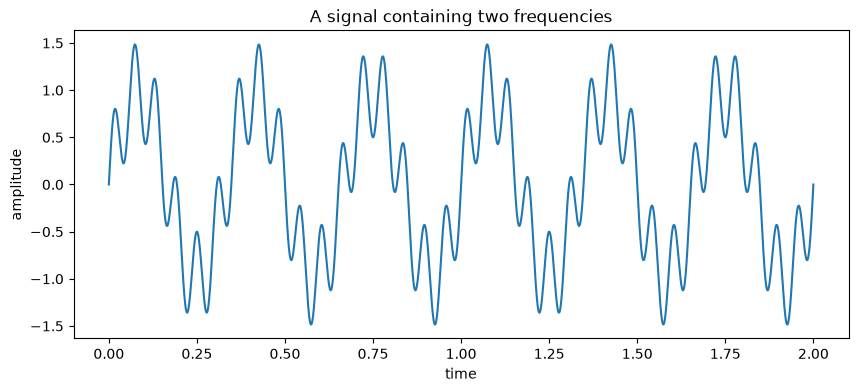

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# A simple signal containing two frequencies.
t = np.linspace(0, 2, 4000)
signal = (
    np.sin(2 * np.pi * 3 * t)
    + 0.5 * np.sin(2 * np.pi * 17 * t)
)

plt.figure(figsize=(10, 4))
plt.plot(t, signal)
plt.xlabel("time")
plt.ylabel("amplitude")
plt.title("A signal containing two frequencies")
plt.show()


## 2. Sampling: from continuous signals to data

A computer receives samples

$$
x_n=x(n\Delta t),
\qquad
n=0,\ldots,N-1.
$$

The sampling frequency is

$$
f_s=\frac{1}{\Delta t}.
$$

The Nyquist frequency is

$$
f_N=\frac{f_s}{2}.
$$

Roughly, a band-limited signal whose highest frequency is below $f_s/2$ can be reconstructed from sufficiently dense uniform samples.

For example, a 44.1 kHz audio sampling rate has Nyquist frequency 22.05 kHz, which is above the approximately 20 kHz upper range of human hearing.

### Aliasing

If a signal contains frequencies above the Nyquist frequency, different continuous signals can produce the same sampled data. This is **aliasing**.

In real measurement systems, an anti-aliasing low-pass filter is commonly applied before sampling.


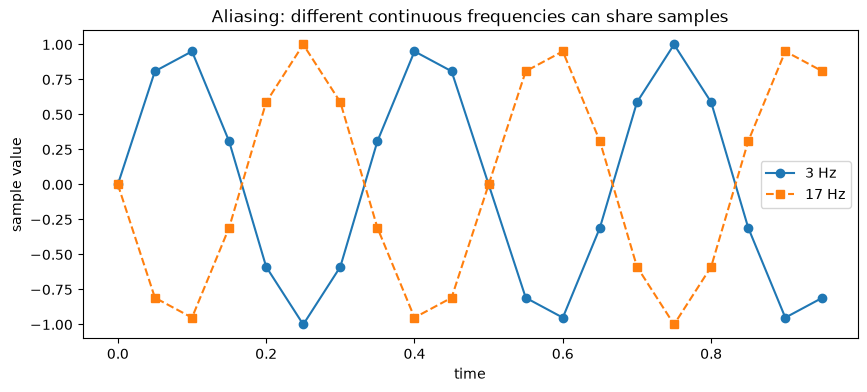

Maximum difference between samples: 2.0


In [2]:
# Demonstrate aliasing.
f_sampling = 20.0
t_samples = np.arange(0, 1, 1 / f_sampling)

f1 = 3.0
f2 = 17.0

x1 = np.sin(2 * np.pi * f1 * t_samples)
x2 = np.sin(2 * np.pi * f2 * t_samples)

plt.figure(figsize=(10, 4))
plt.plot(t_samples, x1, "o-", label="3 Hz")
plt.plot(t_samples, x2, "s--", label="17 Hz")
plt.xlabel("time")
plt.ylabel("sample value")
plt.title("Aliasing: different continuous frequencies can share samples")
plt.legend()
plt.show()

print("Maximum difference between samples:", np.max(np.abs(x1 - x2)))


## 3. Filtering and convolution

A filter modifies selected components of a signal.

A moving-average filter is

$$
y_n=\frac1M\sum_{k=0}^{M-1}x_{n-k}.
$$

This is a discrete convolution:

$$
y=x*h.
$$

Filtering can therefore be understood either in the signal domain or in the Fourier domain:

$$
\widehat y(\omega)
=
\widehat x(\omega)\widehat h(\omega).
$$

A low-pass filter suppresses rapid variation; a high-pass filter suppresses slow variation.

This is the basic signal-processing interpretation of convolution.


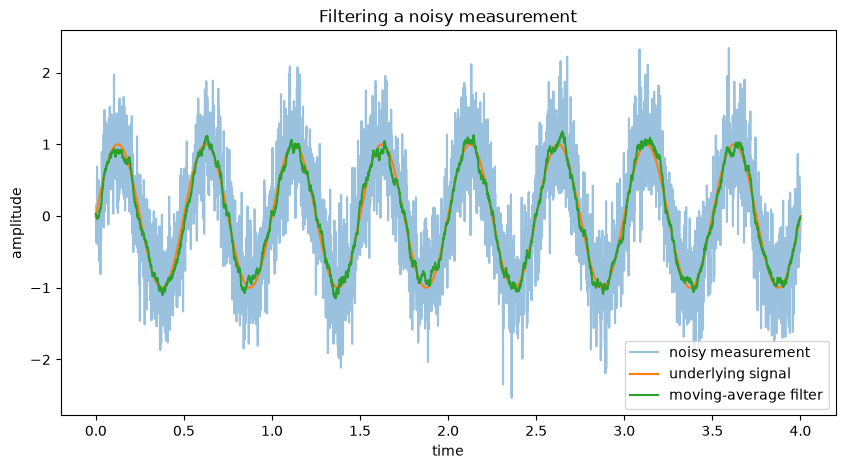

In [3]:
# Moving-average filtering of a noisy signal.
rng = np.random.default_rng(7)

t = np.linspace(0, 4, 4000)
clean = np.sin(2 * np.pi * 2 * t)
noisy = clean + 0.45 * rng.normal(size=len(t))

window = 31
kernel = np.ones(window) / window
smoothed = np.convolve(noisy, kernel, mode="same")

plt.figure(figsize=(10, 5))
plt.plot(t, noisy, alpha=0.45, label="noisy measurement")
plt.plot(t, clean, label="underlying signal")
plt.plot(t, smoothed, label="moving-average filter")
plt.xlabel("time")
plt.ylabel("amplitude")
plt.title("Filtering a noisy measurement")
plt.legend()
plt.show()


## 4. Why Fourier analysis is not enough

Fourier analysis represents a signal using global oscillatory modes

$$
e^{i\omega t}.
$$

This is excellent for stationary frequency content.

But consider

$$
x(t)
=
\sin(2\pi 2t)
+
\mathbf 1_{[1.5,2]}(t)\sin(2\pi 35t).
$$

The Fourier transform can reveal that frequencies around 2 Hz and 35 Hz are present, but it does not directly encode that the 35 Hz activity occurs only near $t\approx1.75$.

This motivates localized representations.

A useful contrast is:

$$
\boxed{\text{Fourier: what frequencies?}}
$$

versus

$$
\boxed{\text{localized representations: what happens where and at what scale?}}
$$


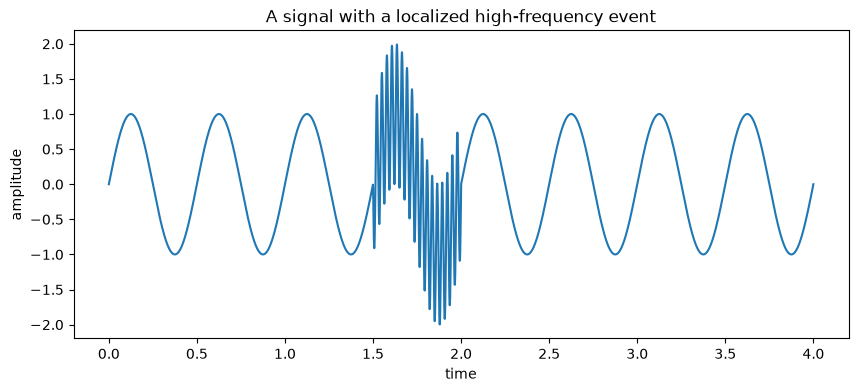

In [4]:
# A low-frequency background plus a localized high-frequency burst.
t = np.linspace(0, 4, 5000)

background = np.sin(2 * np.pi * 2 * t)
burst_window = (t > 1.5) & (t < 2.0)
burst = burst_window * np.sin(2 * np.pi * 35 * t)
transient_signal = background + burst

plt.figure(figsize=(10, 4))
plt.plot(t, transient_signal)
plt.xlabel("time")
plt.ylabel("amplitude")
plt.title("A signal with a localized high-frequency event")
plt.show()


## 5. Short-time Fourier transform

The short-time Fourier transform (STFT) multiplies the signal by a moving window:

$$
V_gx(u,\omega)
=
\int
x(t)g(t-u)e^{-i\omega t}\,dt.
$$

For each location $u$, we examine frequencies near that location.

The tradeoff is fundamental:

- narrow window: good temporal localization, poor frequency resolution;
- wide window: poor temporal localization, good frequency resolution.
  
This is the mathematical analogue of the `Heisenberg Uncertainty Principle`. 
The window $g(t-u)$ determines how much of the signal around time $u$ we inspect.

If $g$ is narrow in time, then we know very accurately where something happens:
$$
\Delta t\ \text{small}.
$$

But the Fourier transform of a narrow function is broad, so the corresponding frequency resolution is poor:
$$
\Delta\omega\ \text{large}.
$$

Conversely,
$$
\Delta t\ \text{large}
\quad\Longrightarrow\quad
\Delta\omega\ \text{small}.
$$

Schematically,
$$
\boxed{\Delta t\,\Delta\omega\gtrsim \text{constant}.}
$$

For the standard deviation definition of localization, one gets the familiar Fourier uncertainty inequality
$$
\sigma_t\sigma_\omega\geq\frac12
$$

when $\omega$ is angular frequency and the Fourier-transform convention is chosen appropriately. The numerical constant changes if frequency is measured in cycles rather than radians.

### The quantum-mechanical analogy is actually very deep

In quantum mechanics,
$$
\Delta x\,\Delta p\geq\frac{\hbar}{2}.
$$

Since momentum is represented in Fourier space,
$$
p=\hbar k,
$$

the quantum-mechanical uncertainty relation is closely connected to the Fourier uncertainty principle.

In signal processing, the analogous pair is
$$
\boxed{
\text{time}\quad\leftrightarrow\quad\text{frequency}.
}
$$

So you can think of the STFT tradeoff as:
$$
\boxed{
\text{time localization}
\quad\leftrightarrow\quad
\text{frequency localization}.
}
$$

The Gabor transform is specifically a windowed Fourier transform, and the time-frequency localization interpretation is standard in harmonic analysis.

Wavelets use a different idea: the effective window size changes with scale.

$$
\boxed{
\text{short windows at high frequencies}
\qquad
\text{long windows at low frequencies}.
}
$$

### And this explains why wavelets are interesting

There is a subtle but important point here.

The STFT uses a fixed window:
$$
g(t-u).
$$

So you have essentially one fixed time-frequency resolution.

Wavelets instead use
$$
\psi_{u,\xi}(t)
=
\frac{1}{\sqrt{\xi}}
\psi\left(\frac{t-u}{\xi}\right).
$$

The window changes with scale.

So we get roughly:
$$
\begin{array}{ccc}
\text{high frequency}
&
\longrightarrow
&
\text{small time window, broad frequency band}
\\[2mm]
\text{low frequency}
&
\longrightarrow
&
\text{large time window, narrow frequency band}.
\end{array}
$$

The uncertainty principle has not been defeated. Wavelets simply distribute the unavoidable uncertainty differently at different scales.

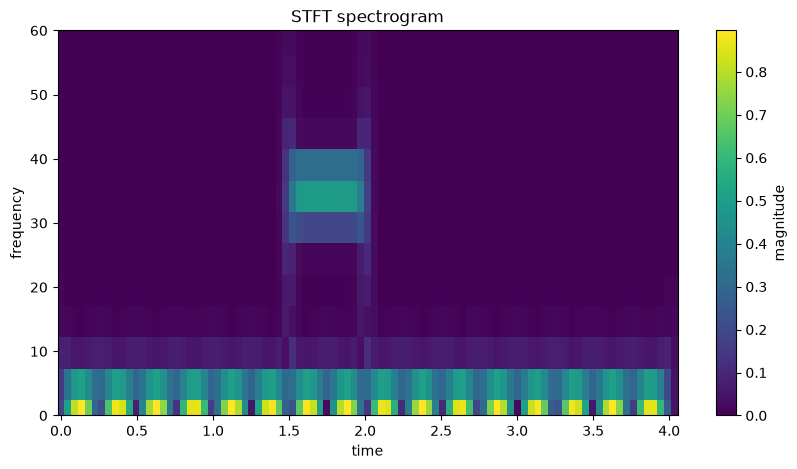

In [5]:
from scipy.signal import stft

# Spectrogram of the transient signal.
frequencies, times, Zxx = stft(
    transient_signal,
    fs=1 / (t[1] - t[0]),
    nperseg=256,
    noverlap=200
)

plt.figure(figsize=(10, 5))
plt.pcolormesh(
    times, frequencies, np.abs(Zxx), shading="auto"
)
plt.ylim(0, 60)
plt.xlabel("time")
plt.ylabel("frequency")
plt.title("STFT spectrogram")
plt.colorbar(label="magnitude")
plt.show()


## 6. Wavelets: localized atoms at different scales

A wavelet starts with a **mother wavelet** $\psi(t)$.

Translated and dilated copies are

$$
\psi_{u,\xi}(t)
=
\xi^{-1/2}
\psi\left(\frac{t-u}{\xi}\right),
$$

where $u$ is position and $\xi$ is scale.

The continuous wavelet transform is

$$
(W_\psi x)(u,\xi)
=
\int
x(v)
\frac{1}{\sqrt{\xi}}
\overline{
\psi\left(\frac{v-u}{\xi}\right)
}
\,dv.
$$

The GDL proto-book emphasizes that wavelet atoms are localized in both space and frequency, with position and dilation providing the coordinates of the transform.

Small $\xi$ means a compressed wavelet and therefore fine-scale structure; large $\xi$ means a broader wavelet and coarse structure.


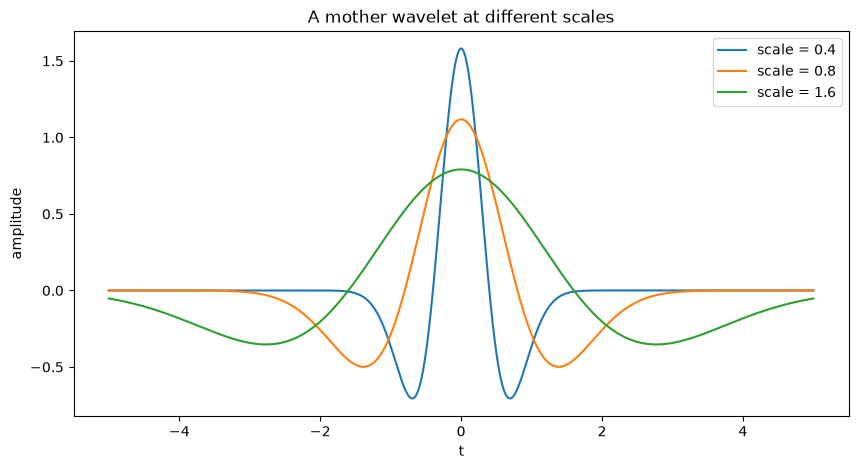

In [6]:
# A simple Mexican-hat-like mother wavelet and its dilations.
t_wave = np.linspace(-5, 5, 2000)

def mexican_hat(t):
    return (1 - t**2) * np.exp(-t**2 / 2)

def wavelet(t, u=0.0, scale=1.0):
    return scale**(-0.5) * mexican_hat((t - u) / scale)

plt.figure(figsize=(10, 5))
for scale in [0.4, 0.8, 1.6]:
    plt.plot(
        t_wave,
        wavelet(t_wave, scale=scale),
        label=f"scale = {scale}"
    )

plt.xlabel("t")
plt.ylabel("amplitude")
plt.title("A mother wavelet at different scales")
plt.legend()
plt.show()


## 7. The Haar wavelet

The Haar wavelet is

$$
\psi(t)=
\begin{cases}
1,&0\leq t<\frac12,\\
-1,&\frac12\leq t<1,\\
0,&\text{otherwise}.
\end{cases}
$$

It compares neighboring regions: one half contributes positively and the other negatively.

Thus it is naturally sensitive to local changes and edges.

**Example:** a signal that is nearly constant across the wavelet support gives a small Haar coefficient.

**Non-example:** a jump crossing the wavelet support can give a large coefficient.

The Haar wavelet is not smooth, but it is ideal for understanding multiresolution because its transform is just a structured change of coordinates.


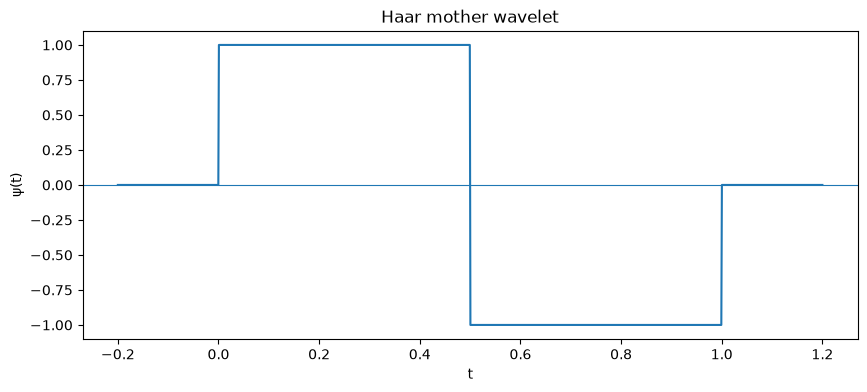

In [7]:
def haar_wavelet(t):
    return np.where(
        (t >= 0) & (t < 0.5),
        1.0,
        np.where((t >= 0.5) & (t < 1.0), -1.0, 0.0)
    )

t_haar = np.linspace(-0.2, 1.2, 1200)

plt.figure(figsize=(10, 4))
plt.plot(t_haar, haar_wavelet(t_haar))
plt.axhline(0, linewidth=0.8)
plt.xlabel("t")
plt.ylabel("ψ(t)")
plt.title("Haar mother wavelet")
plt.show()


## 8. Haar wavelets as averages and differences

For a pair $(x_1,x_2)$, define

$$
\begin{pmatrix}
a\\
d
\end{pmatrix}
=
\frac1{\sqrt2}
\begin{pmatrix}
1&1\\
1&-1
\end{pmatrix}
\begin{pmatrix}
x_1\\
x_2
\end{pmatrix}.
$$

The coefficient $a$ measures coarse content, while $d$ measures local variation.

This is simply a change of basis.

The remarkable idea is that we repeat this operation on the coarse coefficients:

$$
x
\rightarrow
(a_1,d_1)
\rightarrow
(a_2,d_2,d_1)
\rightarrow
\cdots.
$$

This recursive separation of coarse information and detail is the essence of **multiresolution analysis**.


In [8]:
# The 2-point Haar transform.
H2 = (1 / np.sqrt(2)) * np.array([
    [1, 1],
    [1, -1]
])

x_pair = np.array([4.0, 6.0])
haar_pair = H2 @ x_pair

print("Original pair:", x_pair)
print("Average-like coefficient:", haar_pair[0])
print("Difference-like coefficient:", haar_pair[1])
print("H^T H =")
print(np.round(H2.T @ H2, 6))


Original pair: [4. 6.]
Average-like coefficient: 7.071067811865475
Difference-like coefficient: -1.414213562373095
H^T H =
[[ 1. -0.]
 [-0.  1.]]


## 9. Recursive multiresolution decomposition

For a signal of length $2^J$, repeated Haar decomposition gives

$$
x
\longrightarrow
(a_J,d_J,d_{J-1},\ldots,d_1).
$$

The $a_J$ coefficient contains the coarsest information.

The $d_j$ coefficients contain detail at progressively finer scales.

Schematically,

$$
\boxed{
\text{coarse approximation}
+
\text{detail at each scale}.
}
$$

Mallat's multiresolution framework formalized the connection between this kind of recursive approximation and wavelet bases of $L^2$.


In [9]:
def haar_step(x):
    # One level of the orthonormal Haar transform.
    x = np.asarray(x, dtype=float)
    if len(x) % 2 != 0:
        raise ValueError("Length must be even.")

    averages = (x[0::2] + x[1::2]) / np.sqrt(2)
    details = (x[0::2] - x[1::2]) / np.sqrt(2)
    return averages, details

def haar_decompose(x):
    # Full multiscale Haar decomposition.
    x = np.asarray(x, dtype=float)
    if len(x) == 0 or (len(x) & (len(x) - 1)) != 0:
        raise ValueError("Length must be a positive power of two.")

    details = []
    current = x.copy()

    while len(current) > 1:
        current, detail = haar_step(current)
        details.append(detail)

    return current, details

x_example = np.array(
    [2, 4, 5, 5, 7, 9, 10, 10], dtype=float
)

coarse, details = haar_decompose(x_example)

print("Coarsest coefficient:", coarse)
for level, detail in enumerate(reversed(details), start=1):
    print(f"Detail level {level}:", detail)


Coarsest coefficient: [18.38477631]
Detail level 1: [-7.07106781]
Detail level 2: [-2. -2.]
Detail level 3: [-1.41421356  0.         -1.41421356  0.        ]


## 10. Wavelets and edges

An idealized edge is

$$
f(t)=
\begin{cases}
0,&t<0,\\
1,&t\geq0.
\end{cases}
$$

A wavelet centered near the edge responds strongly when its support overlaps the transition.

At different scales, we see the edge at different resolutions.

Thus wavelet coefficients can encode both:

$$
\text{where is the change?}
$$

and

$$
\text{at what scale is the change visible?}
$$

This is one reason wavelets became important in image processing and singularity/edge detection. Mallat's work explicitly develops these applications.


<Figure size 1000x500 with 0 Axes>

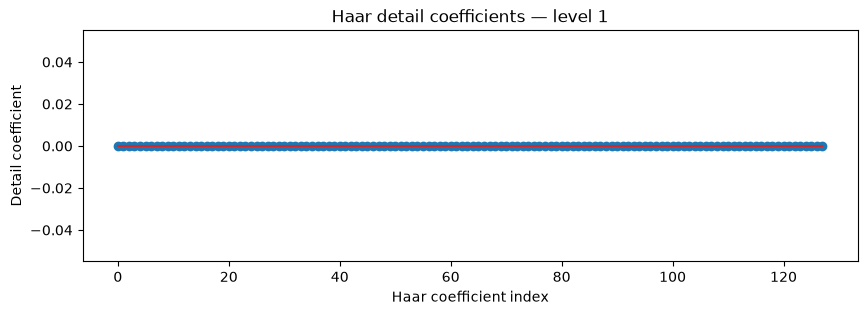

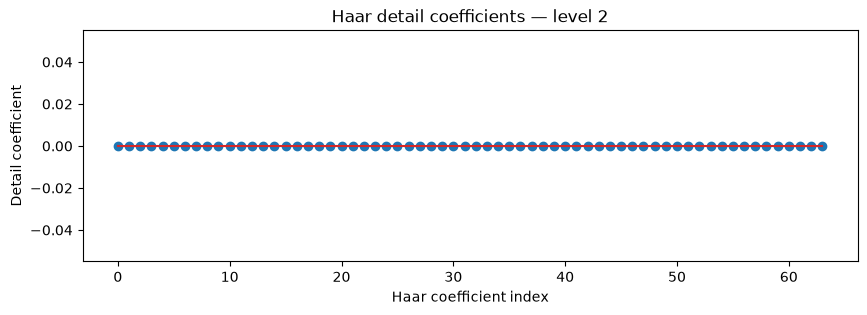

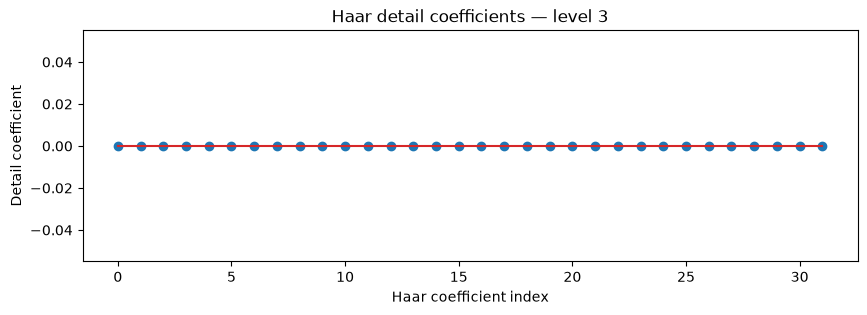

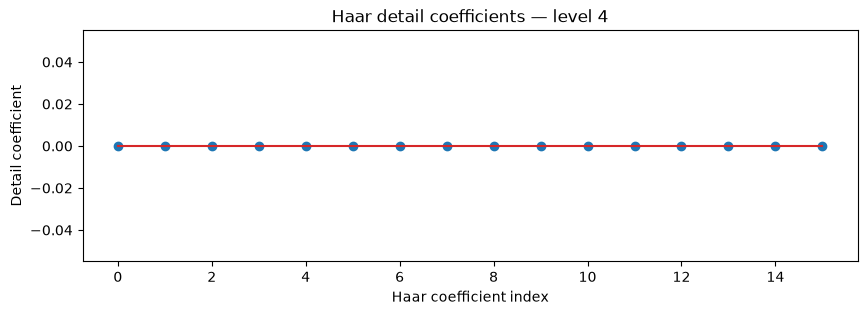

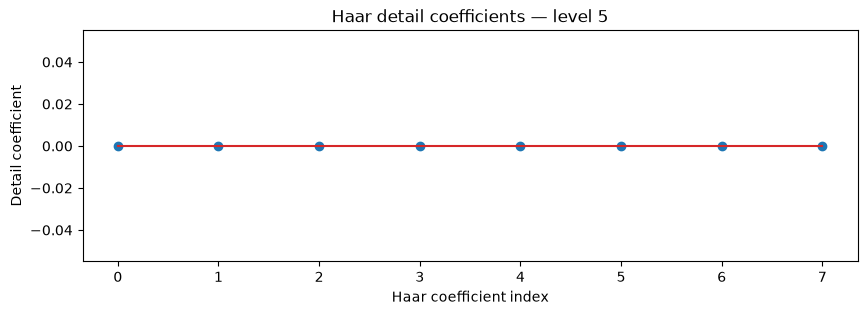

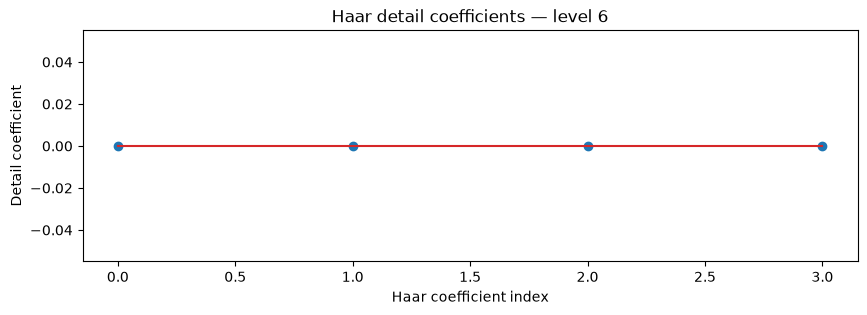

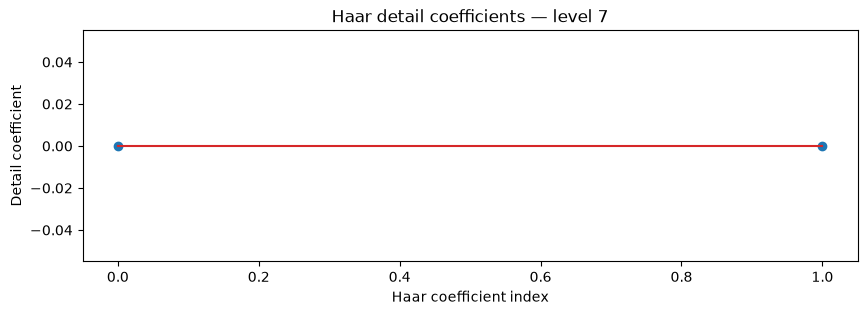

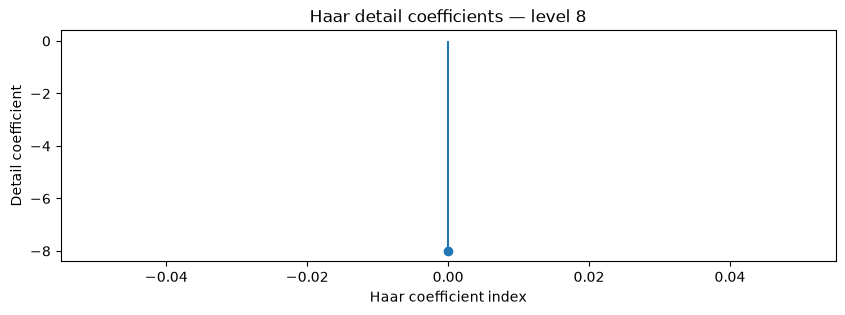

In [11]:
# Haar detail coefficients of a simple step.
N = 256
edge_signal = np.zeros(N)
edge_signal[N // 2:] = 1.0

coarse, edge_details = haar_decompose(edge_signal)

plt.figure(figsize=(10, 5))
for i, detail in enumerate(edge_details):
    plt.figure(figsize=(10, 3))

    plt.stem(
        np.arange(len(detail)),
        detail
    )

    plt.xlabel("Haar coefficient index")
    plt.ylabel("Detail coefficient")
    plt.title(f"Haar detail coefficients — level {i + 1}")
    plt.show()


## 11. Real-life example: image edges and texture

An image is a two-dimensional signal

$$
I:\Omega\subset\mathbb R^2\to\mathbb R.
$$

Important image structures occur at different scales:

- large objects and smooth regions;
- object boundaries;
- fine texture;
- small isolated features.

A two-dimensional wavelet decomposition separates coarse information from detail. In separable constructions, detail channels can be interpreted as horizontal, vertical, and diagonal structure.

This is a natural fit for images because edges and textures are spatially localized.


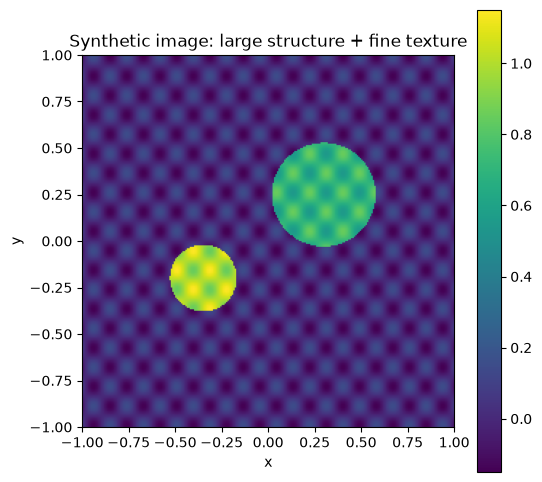

In [12]:
# Synthetic image containing large objects and fine texture.
n = 256
xx = np.linspace(-1, 1, n)
yy = np.linspace(-1, 1, n)
X, Y = np.meshgrid(xx, yy)

large_structure = (
    ((X + 0.35)**2 + (Y + 0.2)**2 < 0.18**2).astype(float)
    + 0.7 * ((X - 0.3)**2 + (Y - 0.25)**2 < 0.28**2).astype(float)
)

texture = 0.15 * np.sin(35 * X) * np.sin(30 * Y)
image = large_structure + texture

plt.figure(figsize=(6, 6))
plt.imshow(image, extent=[-1, 1, -1, 1], origin="lower")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic image: large structure + fine texture")
plt.colorbar()
plt.show()


## 12. Real-life example: denoising

Suppose

$$
y=x+\eta,
$$

where $\eta$ is noise.

A simple wavelet-denoising procedure is:

1. transform $y$ into wavelet coefficients;
2. identify small coefficients likely to be noise;
3. shrink or remove them;
4. reconstruct.

Hard thresholding is

$$
\widetilde c=
\begin{cases}
0,&|c|<\lambda,\\
c,&|c|\geq\lambda.
\end{cases}
$$

Soft thresholding is

$$
\widetilde c
=
\operatorname{sign}(c)\max(|c|-\lambda,0).
$$

Natural signals often have relatively sparse wavelet representations, while noise can populate many coefficients. This makes thresholding useful for denoising and estimation.


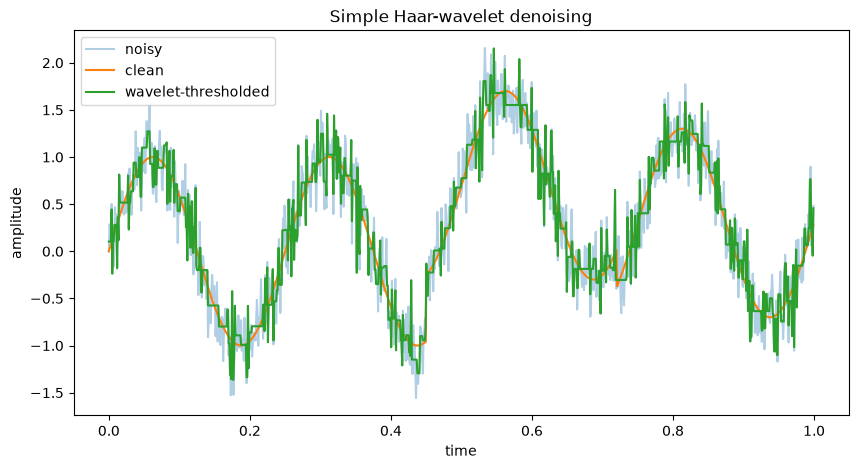

In [13]:
def haar_reconstruct(coarse, details):
    # Reconstruct a signal from its Haar coefficients.
    current = np.asarray(coarse, dtype=float).copy()

    for detail in reversed(details):
        detail = np.asarray(detail, dtype=float)
        current = np.column_stack([
            (current + detail) / np.sqrt(2),
            (current - detail) / np.sqrt(2)
        ]).ravel()

    return current

N = 1024
t = np.linspace(0, 1, N, endpoint=False)

clean = (
    np.sin(2 * np.pi * 4 * t)
    + 0.7 * (t > 0.45)
    - 0.4 * (t > 0.72)
)

rng = np.random.default_rng(12)
noisy = clean + 0.25 * rng.normal(size=N)

coarse, details = haar_decompose(noisy)

threshold = 0.35
thresholded_details = [
    np.where(np.abs(d) >= threshold, d, 0.0)
    for d in details
]

denoised = haar_reconstruct(coarse, thresholded_details)

plt.figure(figsize=(10, 5))
plt.plot(t, noisy, alpha=0.35, label="noisy")
plt.plot(t, clean, label="clean")
plt.plot(t, denoised, label="wavelet-thresholded")
plt.xlabel("time")
plt.ylabel("amplitude")
plt.title("Simple Haar-wavelet denoising")
plt.legend()
plt.show()


## 13. Real-life example: ECG signals

An electrocardiogram (ECG) is a time-dependent electrical signal generated by the heart.

It contains structures such as the P wave, QRS complex, and T wave. These have different temporal scales: the QRS complex is much sharper than the surrounding components.

This makes multiscale analysis natural:

$$
\text{slow components}
\leftrightarrow
\text{coarser scales}
$$

and

$$
\text{sharp transient components}
\leftrightarrow
\text{finer scales}.
$$

Wavelets have therefore been widely studied for ECG denoising, feature extraction, and transient detection.

The example below is deliberately synthetic: it illustrates the signal-processing idea without pretending to be a clinical ECG model.


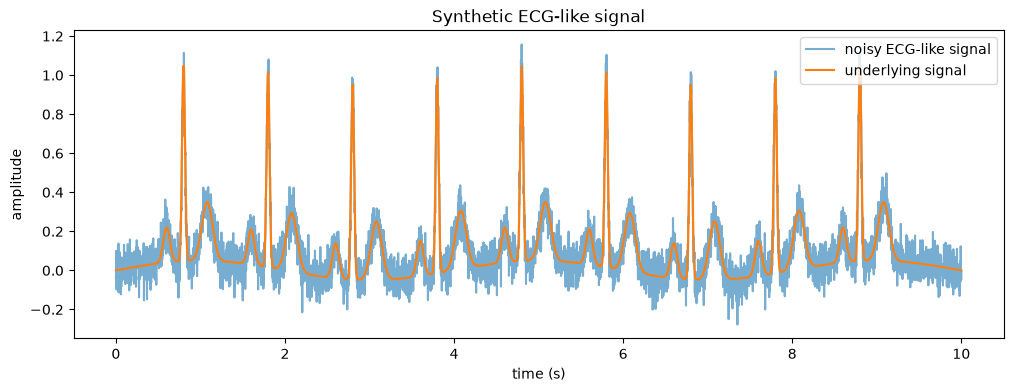

In [14]:
# Synthetic ECG-like signal.
t_ecg = np.linspace(0, 10, 5000)
baseline = 0.05 * np.sin(2 * np.pi * 0.25 * t_ecg)
ecg_like = baseline.copy()

heartbeats = np.arange(0.8, 9.6, 1.0)

for center in heartbeats:
    qrs = np.exp(-((t_ecg - center) / 0.025)**2)
    p_wave = 0.18 * np.exp(-((t_ecg - (center - 0.20)) / 0.055)**2)
    t_wave = 0.30 * np.exp(-((t_ecg - (center + 0.28)) / 0.09)**2)
    ecg_like += qrs + p_wave + t_wave

rng = np.random.default_rng(4)
ecg_noisy = ecg_like + 0.06 * rng.normal(size=len(t_ecg))

plt.figure(figsize=(12, 4))
plt.plot(t_ecg, ecg_noisy, alpha=0.6, label="noisy ECG-like signal")
plt.plot(t_ecg, ecg_like, label="underlying signal")
plt.xlabel("time (s)")
plt.ylabel("amplitude")
plt.title("Synthetic ECG-like signal")
plt.legend()
plt.show()


## 14. Real-life example: seismic signals

Seismic recordings may contain:

- slow background oscillations;
- wave arrivals;
- sharp transients;
- reverberations;
- multiple frequency bands.

The arrival time of a transient can be important, so a representation that records both location and scale is useful.

The same mathematical pattern appears in many sensor systems:

$$
\text{signal}
=
\text{slow component}
+
\text{localized events}
+
\text{noise}.
$$

Wavelet analysis is particularly suited to transient and multiscale phenomena.


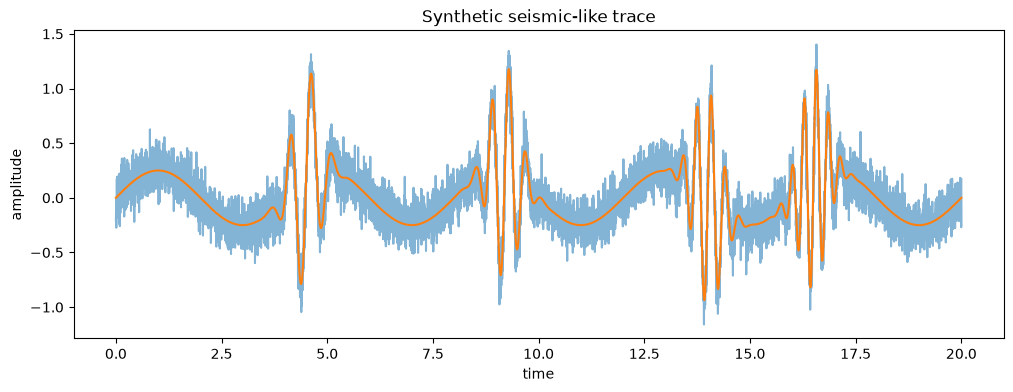

In [15]:
# Synthetic seismic-like trace with localized arrivals.
t_seismic = np.linspace(0, 20, 8000)
background = 0.25 * np.sin(2 * np.pi * 0.25 * t_seismic)
seismic = background.copy()

arrival_times = [4.5, 9.2, 14.0, 16.5]

for i, center in enumerate(arrival_times):
    frequency = 2.0 + 0.5 * i
    envelope = np.exp(-((t_seismic - center) / 0.45)**2)
    seismic += envelope * np.sin(
        2 * np.pi * frequency * (t_seismic - center)
    )

rng = np.random.default_rng(8)
seismic_noisy = seismic + 0.12 * rng.normal(size=len(t_seismic))

plt.figure(figsize=(12, 4))
plt.plot(t_seismic, seismic_noisy, alpha=0.55)
plt.plot(t_seismic, seismic)
plt.xlabel("time")
plt.ylabel("amplitude")
plt.title("Synthetic seismic-like trace")
plt.show()


## 15. Real-life example: audio and musical transients

Audio contains both sustained and transient phenomena.

Examples include:

- a sustained violin note;
- a flute tone;
- a drum strike;
- a cymbal crash;
- speech consonants;
- rapidly changing frequency sweeps.

Fourier analysis is excellent for sustained frequency content.

Wavelets and time-frequency methods become especially useful when the signal changes rapidly in time.

A useful heuristic is therefore

$$
\text{stationary oscillation}
\longrightarrow
\text{Fourier},
$$

whereas

$$
\text{localized transient}
\longrightarrow
\text{time-frequency / wavelet representation}.
$$

Mallat's text includes time-frequency audio processing and denoising among its applications.


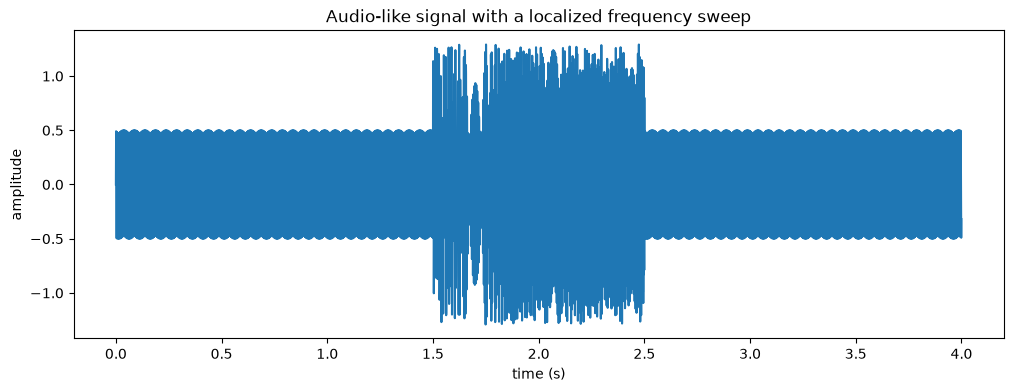

In [16]:
from scipy.signal import chirp

# Audio-like signal: sustained tone plus localized chirp.
fs = 2000
duration = 4
t_audio = np.arange(0, duration, 1 / fs)

tone = 0.5 * np.sin(2 * np.pi * 220 * t_audio)
transient = np.zeros_like(t_audio)

mask = (t_audio >= 1.5) & (t_audio <= 2.5)
transient[mask] = 0.8 * chirp(
    t_audio[mask] - 1.5,
    f0=100,
    f1=700,
    t1=1.0,
    method="linear"
)

audio_like = tone + transient

plt.figure(figsize=(12, 4))
plt.plot(t_audio, audio_like)
plt.xlabel("time (s)")
plt.ylabel("amplitude")
plt.title("Audio-like signal with a localized frequency sweep")
plt.show()


## 16. Compression and sparsity

Suppose a signal has wavelet coefficients

$$
(c_1,\ldots,c_N).
$$

If most coefficients are small, we can retain only the largest coefficients and reconstruct an approximation:

$$
\widetilde x
=
\sum_i\widetilde c_i\psi_i.
$$

The idea is

$$
\boxed{\text{good representation}\approx\text{few significant coefficients}.}
$$

This is **sparsity**.

Wavelet representations have been used in signal and image compression, including JPEG 2000. Mallat's treatment also connects wavelets to sparse representations, denoising, inverse problems, and image processing.


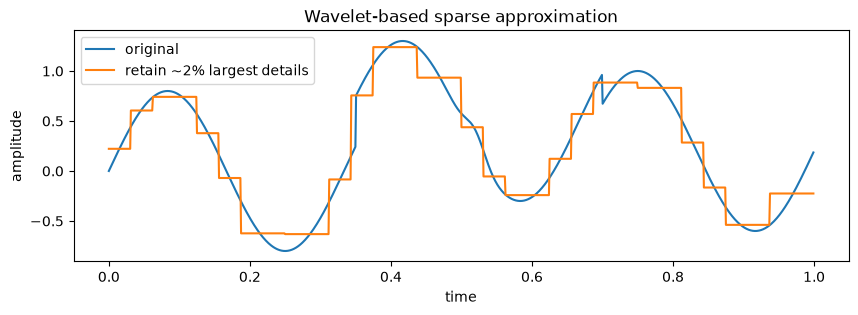

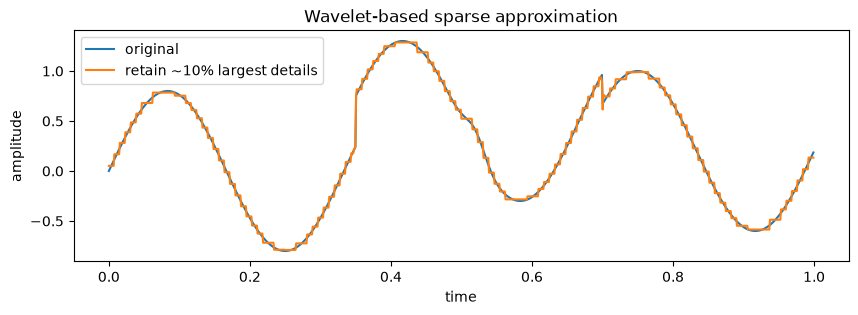

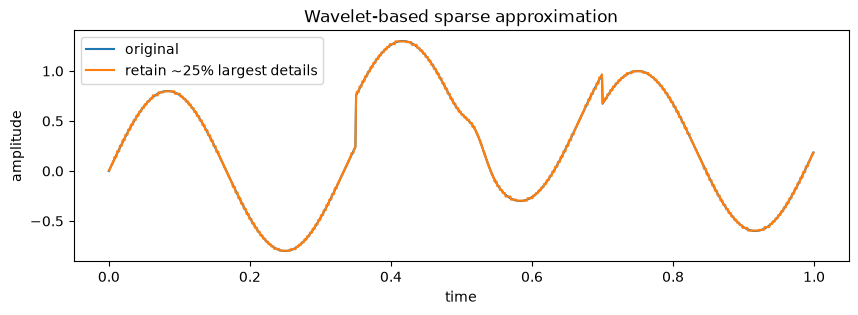

In [17]:
# Sparse approximation using Haar detail coefficients.
N = 1024
t = np.linspace(0, 1, N, endpoint=False)

signal_for_compression = (
    0.8 * np.sin(2 * np.pi * 3 * t)
    + 0.5 * (t > 0.35)
    - 0.3 * (t > 0.70)
    + 0.2 * np.exp(-((t - 0.52) / 0.02)**2)
)

coarse, details = haar_decompose(signal_for_compression)
all_details = np.concatenate(details)

for fraction in [0.02, 0.10, 0.25]:
    threshold = np.quantile(np.abs(all_details), 1 - fraction)
    sparse_details = [
        np.where(np.abs(d) >= threshold, d, 0.0)
        for d in details
    ]
    reconstructed = haar_reconstruct(coarse, sparse_details)

    plt.figure(figsize=(10, 3))
    plt.plot(t, signal_for_compression, label="original")
    plt.plot(
        t, reconstructed,
        label=f"retain ~{100*fraction:.0f}% largest details"
    )
    plt.xlabel("time")
    plt.ylabel("amplitude")
    plt.legend()
    plt.title("Wavelet-based sparse approximation")
    plt.show()


## 17. Fourier versus wavelets

### Fourier representation

The basis functions

$$
e^{i\omega t}
$$

are global.

A Fourier coefficient answers:

$$
\text{How much of frequency }\omega\text{ is present?}
$$

### Wavelet representation

The atoms

$$
\psi_{u,\xi}(t)
=
\xi^{-1/2}\psi\left(\frac{t-u}{\xi}\right)
$$

have location and scale.

A wavelet coefficient answers something closer to:

$$
\text{How much localized structure of scale }\xi
\text{ occurs near }u?
$$

Thus

$$
\boxed{\text{Fourier = global frequency}}
$$

while

$$
\boxed{\text{wavelets = local scale + location}.}
$$

The proto-book emphasizes precisely this tradeoff between global frequency information and localized multiscale representations.


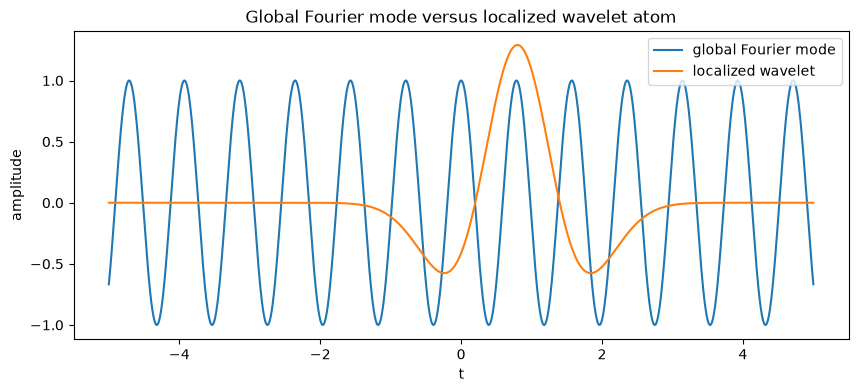

In [18]:
# Visual comparison of a global Fourier mode and a localized wavelet atom.
t_compare = np.linspace(-5, 5, 2000)

fourier_mode = np.cos(8 * t_compare)
localized_wavelet = wavelet(t_compare, u=0.8, scale=0.6)

plt.figure(figsize=(10, 4))
plt.plot(t_compare, fourier_mode, label="global Fourier mode")
plt.plot(t_compare, localized_wavelet, label="localized wavelet")
plt.xlabel("t")
plt.ylabel("amplitude")
plt.title("Global Fourier mode versus localized wavelet atom")
plt.legend()
plt.show()


## 18. Continuous versus discrete wavelets

A continuous wavelet transform examines a continuum of translations and scales:

$$
(W_\psi x)(u,\xi).
$$

A discrete wavelet transform samples them, commonly dyadically:

$$
\xi=2^{-j},
\qquad
u=2^{-j}k.
$$

The continuous transform is conceptually useful because it reveals the full position-scale structure.

The discrete transform is computationally important because it leads to efficient filter-bank algorithms.

Thus

$$
\text{continuous wavelet transform}
\longrightarrow
\text{analysis and visualization},
$$

while

$$
\text{discrete wavelet transform}
\longrightarrow
\text{efficient computation and representation}.
$$


## 19. Filter banks

A discrete wavelet transform can be interpreted as a sequence of low-pass and high-pass filters.

At one level:

$$
x
\longrightarrow
\begin{cases}
\text{low-pass}\\
\text{high-pass}
\end{cases}.
$$

The low-pass output is then decomposed again:

$$
\text{low-pass}
\longrightarrow
\begin{cases}
\text{lower-frequency low-pass}\\
\text{detail}
\end{cases}.
$$

This gives a hierarchy of frequency/scale bands.

The mathematical viewpoint is

$$
\text{wavelet basis}
\longleftrightarrow
\text{multiscale decomposition},
$$

while the engineering viewpoint is

$$
\text{wavelet transform}
\longleftrightarrow
\text{filter bank}.
$$

Mallat's fast wavelet transform makes this connection explicit.


## 20. Wavelets are not necessarily orthonormal bases

It is tempting to assume that every wavelet system behaves exactly like an orthonormal Fourier basis.

That is not true.

Wavelet constructions include:

- orthonormal bases;
- biorthogonal bases;
- frames;
- redundant or overcomplete systems.

The GDL proto-book explicitly describes wavelet atoms in a redundant/overcomplete representation. citeturn1search17

The distinction matters:

$$
\text{basis}
\quad\Rightarrow\quad
\text{unique coordinates under the basis assumptions},
$$

whereas

$$
\text{redundant dictionary}
\quad\Rightarrow\quad
\text{potentially multiple representations}.
$$

Redundancy can nevertheless be useful for stability and flexibility.


## 21. Deformation stability

This is the key GDL motivation.

Consider a small deformation

$$
\tau(t)=t-\delta(t).
$$

For a Fourier mode,

$$
e^{i\omega t}
\longrightarrow
e^{i\omega(t-\delta(t))}
=
e^{i\omega t}e^{-i\omega\delta(t)}.
$$

Even if $\delta(t)$ is small, the phase change

$$
\omega\delta(t)
$$

can be large when $\omega$ is large.

Thus high-frequency Fourier representations can be sensitive to small non-rigid deformations.

The proto-book contrasts this with localized wavelet representations, which can provide improved stability under small deformations.


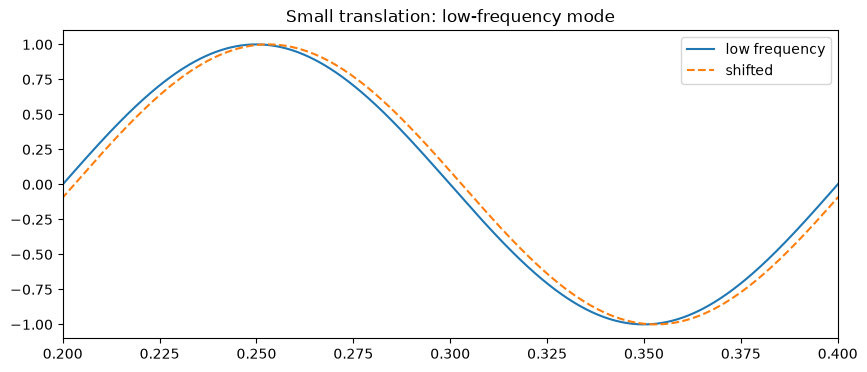

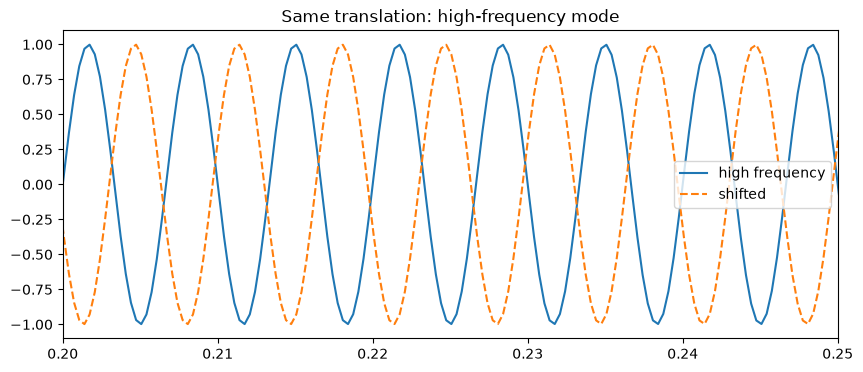

In [19]:
# The same small translation produces a much larger phase change
# for a high-frequency oscillation.
t = np.linspace(0, 1, 3000)
small_shift = 0.003

low_frequency = np.sin(2 * np.pi * 5 * t)
high_frequency = np.sin(2 * np.pi * 150 * t)

low_shifted = np.sin(2 * np.pi * 5 * (t - small_shift))
high_shifted = np.sin(2 * np.pi * 150 * (t - small_shift))

plt.figure(figsize=(10, 4))
plt.plot(t, low_frequency, label="low frequency")
plt.plot(t, low_shifted, "--", label="shifted")
plt.xlim(0.2, 0.4)
plt.title("Small translation: low-frequency mode")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(t, high_frequency, label="high frequency")
plt.plot(t, high_shifted, "--", label="shifted")
plt.xlim(0.2, 0.25)
plt.title("Same translation: high-frequency mode")
plt.legend()
plt.show()


## 22. Why localization helps

Suppose a signal contains a localized feature around $u_0$, a point in the domain of the signal.

A wavelet centered near $u_0$ interacts strongly only with a neighborhood of $u_0$. Under a small deformation, that neighborhood moves slightly.

Schematically,

$$
W_\psi(\rho(\tau)x)
\approx
\rho(\tau)(W_\psi x).
$$

The proto-book describes this as approximate equivariance of wavelet decompositions and contrasts it with the instability of Fourier decompositions under high-frequency deformations.

The conceptual point is

$$
\boxed{
\text{localization turns sensitivity to deformation into controlled motion across location and scale}.
}
$$


## 23. Scale is not exactly frequency

These notions are closely related, but they are not identical.

For a Fourier mode,

$$
e^{i\omega t},
$$

$\omega$ is a frequency.

For a wavelet,

$$
\psi_{u,\xi}(t),
$$

$\xi$ is a scale.

Roughly,

$$
\text{small scale}
\leftrightarrow
\text{high-frequency behavior},
$$

and

$$
\text{large scale}
\leftrightarrow
\text{low-frequency behavior}.
$$

But a wavelet at a given scale occupies a **band of frequencies**, not one exact frequency.

This distinction is important when moving between Fourier and wavelet language.


## 24. Position-scale space

The wavelet transform creates a new representation indexed by

$$
(u,\xi).
$$

The original signal lives on

$$
t\in\mathbb R,
$$

whereas the transformed representation lives on a position-scale domain:

$$
(u,\xi)\in\mathbb R\times\mathbb R_{>0}.
$$

Thus a one-dimensional signal has been lifted to a two-dimensional representation.

For images, one can similarly have

$$
(x,y,\text{scale},\text{orientation}).
$$

This geometric viewpoint will be useful later when we study representations on graphs and manifolds.


## 25. Scattering: one route toward geometric deep learning

Wavelets also lead toward the **scattering transform**.

Schematically, a first-order scattering operation applies a wavelet and a pointwise nonlinearity:

$$
x*\psi_\lambda
\longrightarrow
|x*\psi_\lambda|.
$$

A second-order coefficient has the form

$$
\left|
|x*\psi_{\lambda_1}|*\psi_{\lambda_2}
\right|.
$$

Scattering representations were developed to study translation invariance and deformation stability. Geometric versions extend the construction to manifolds and other geometric domains.

We will not develop scattering networks here, but the conceptual chain is useful:

$$
\boxed{
\text{wavelets}
\rightarrow
\text{multiscale nonlinear representations}
\rightarrow
\text{scattering}
\rightarrow
\text{geometric scattering}.
}
$$


## 26. When should we use Fourier, STFT, or wavelets?

There is no universally best representation.

| Signal structure | Natural representation |
|---|---|
| stationary periodic oscillation | Fourier |
| approximately stationary spectrum | Fourier / spectral methods |
| time-varying frequency | STFT |
| localized transient | wavelets |
| sharp edge | wavelets |
| multiscale structure | wavelets |
| sparse localized features | wavelets / sparse dictionaries |
| translation-equivariant filtering | Fourier / convolution |
| deformation-stable localized features | wavelet-type representations |

These are heuristics, not rigid rules. The correct representation depends on the geometry and statistical structure of the data.


## 27. Examples and non-examples

### Example: pure sine wave

$$
x(t)=\sin(2\pi ft).
$$

A Fourier representation is extremely compact.

### Example: localized burst

A wavelet representation is natural because the event is localized in both time and scale.

### Example: image edge

Wavelet coefficients can concentrate information near the edge at appropriate scales.

### Example: noisy sensor signal

Wavelet thresholding can separate structured coefficients from many small noise coefficients.

### Non-example: treating every signal as stationary

A global Fourier spectrum does not tell us when a transient occurred.

### Non-example: assuming "wavelet" means one unique transform

There are many wavelet families and constructions, with different support, regularity, redundancy, and other properties.

### Non-example: identifying scale with one exact frequency

A wavelet is localized in frequency but generally occupies a frequency band.


## 28. Connection to Geometric Deep Learning

The deeper question is not simply

> Which transform should we use?

It is

> **Which representation reflects the structure of the domain and the transformations relevant to the task?**

For Euclidean signals,

$$
\text{translations}
\longrightarrow
\text{Fourier/convolution}.
$$

For localized multiscale structure,

$$
\text{position + scale}
\longrightarrow
\text{wavelet representations}.
$$

For graphs,

$$
\text{graph Laplacian}
\longrightarrow
\text{graph spectral modes}.
$$

For manifolds,

$$
\text{Laplace--Beltrami operator}
\longrightarrow
\text{geometric spectral modes}.
$$

The common pattern is

$$
\boxed{
\text{geometry}
\rightarrow
\text{natural operators/symmetries}
\rightarrow
\text{adapted representations}
\rightarrow
\text{stable computations}.
}
$$

This is the broader geometric-deep-learning perspective.


## 29. Exercises

### Exercise 1 — Sampling

A signal contains frequencies up to $8$ kHz. What sampling frequency is required by the Nyquist criterion? What practical issue may require choosing a higher sampling rate?

### Exercise 2 — Aliasing

Construct two different-frequency sinusoids that produce the same samples at a chosen sampling frequency.

### Exercise 3 — Filtering

Apply moving-average filters with windows $5$, $25$, and $101$ to a noisy signal. What happens to fine-scale structure?

### Exercise 4 — STFT

Experiment with different `nperseg` values in the spectrogram. Compare time and frequency resolution.

### Exercise 5 — Haar transform

For

$$
x=(1,3,5,7),
$$

compute the first Haar decomposition by hand, then decompose the coarse coefficients.

### Exercise 6 — Edge detection

Construct a piecewise-constant signal with several jumps and use Haar detail coefficients to locate the jumps.

### Exercise 7 — Denoising

Generate a smooth signal with Gaussian noise and investigate the reconstruction error as the Haar threshold varies.

### Exercise 8 — Compression

Keep only $1\%$, $5\%$, $10\%$, and $25\%$ of the largest Haar detail coefficients. Plot reconstruction error versus retained fraction.

### Exercise 9 — Scale and frequency

Construct a localized high-frequency burst and a broad low-frequency oscillation. Which wavelet scales should respond most strongly?

### Exercise 10 — Deformation

Apply the same small translation to low- and high-frequency sinusoids. Compare their relative $L^2$ changes.

### Exercise 11 — Image processing

Construct an image containing a smooth region, a sharp edge, and fine texture. Investigate which structures disappear first under smoothing.

### Exercise 12 — GDL

Suppose

$$
Lu_i=\lambda_i u_i.
$$

Explain how $h(L)$ acts as a spectral filter and how this relates to the wavelet idea of filtering at multiple scales.


## 30. Summary

The central lesson is choosing a representation adapted to the signal.

Fourier analysis gives

$$
\text{signal}
\longrightarrow
\text{global frequencies}.
$$

Wavelet analysis gives

$$
\text{signal}
\longrightarrow
\text{localized structures across scales}.
$$

The wavelet atom

$$
\psi_{u,\xi}(t)
=
\xi^{-1/2}
\psi\left(\frac{t-u}{\xi}\right)
$$

contains two important parameters:

$$
u=\text{position},
\qquad
\xi=\text{scale}.
$$

Wavelets are particularly useful for transients, edges, nonstationary signals, denoising, compression, sparse representation, and deformation-stable features.

The GDL connection is

$$
\boxed{
\text{representation should reflect geometry and relevant transformations}.
}
$$

This is why wavelets belong naturally in the GDL story.


## References

### Geometric Deep Learning

1. M. M. Bronstein, J. Bruna, T. Cohen, and P. Veličković, **Geometric Deep Learning: Grids, Groups, Graphs, Geodesics, and Gauges**, arXiv:2104.13478, especially §3.4, *Scale Separation*.  
   https://arxiv.org/abs/2104.13478

2. H. Sáez de Ocáriz Borde and M. Bronstein, **Mathematical Foundations of Geometric Deep Learning**, arXiv:2508.02723.  
   https://arxiv.org/abs/2508.02723

### Wavelets and signal processing

3. S. Mallat, **A Wavelet Tour of Signal Processing: The Sparse Way**, 3rd ed., Academic Press, 2009.  
   The main outside reference for this notebook. It develops Fourier analysis, time-frequency methods, multiresolution, wavelet bases, filter banks, denoising, compression, and sparse representations, with applications to image processing, audio, biomedical sensing, and communications.

4. S. Mallat, **A Theory for Multiresolution Signal Decomposition: The Wavelet Representation**, IEEE Transactions on Pattern Analysis and Machine Intelligence 11 (1989), 674–693.

5. S. Mallat, **Multiresolution Approximation and Wavelet Orthonormal Bases of $L^2$**, Transactions of the American Mathematical Society 315 (1989), 69–87.

### Fourier and mathematical background

6. E. M. Stein and R. Shakarchi, **Fourier Analysis: An Introduction**, Princeton University Press.

7. G. F. Simmons, **Differential Equations with Applications and Historical Notes**, McGraw-Hill.  
   Used in the preceding Fourier-analysis notebook for the eigenfunction-expansion viewpoint.

### Wavelets and geometric learning

8. **Geometric Wavelet Scattering Networks on Compact Riemannian Manifolds**, for the connection between wavelet scattering, deformation stability, and geometric domains.

### Further reading

Mallat's book is particularly valuable for continuing beyond this notebook: its treatment includes time-frequency atoms, windowed Fourier transforms, wavelet zoom, wavelet bases, wavelet/filter-bank algorithms, sparse approximation, denoising, compression, and geometric extensions.
